Modulasjonsorden med størst margin: 4
Største margin: 23.09 dB
Symbolrate: 5466.67 Hz , 37.4 dBHz
Eb/N0: 33.62 dB
Eb/N0 krav: 10.53 dB


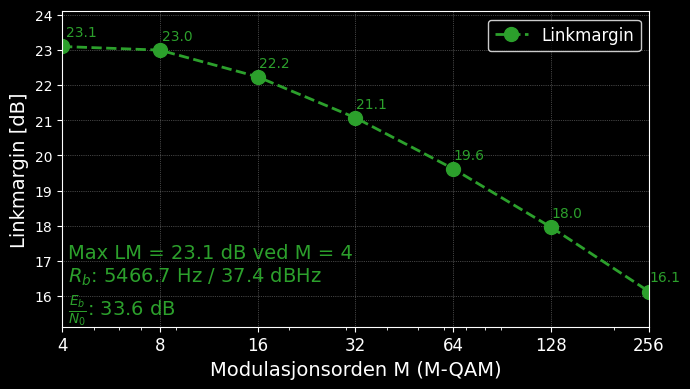

In [1]:
import numpy as np
from scipy.special import erfcinv
import matplotlib.pyplot as plt
plt.style.use('dark_background')

def Eb_N0_krav_func(M, BER):
    k = np.log2(M)
    inv_arg = 2 * BER * k / (4 * (1 - 1/np.sqrt(M)))
    Qinv = np.sqrt(2) * erfcinv(inv_arg)
    EbN0_lin = (M - 1) / (3 * k) * Qinv**2
    return 10 * np.log10(EbN0_lin)  # i dB

# Gitte parametere
bit_mengde = 32.8e6  # Bits
sende_tid = 50 * 60  # sekunder
bit_rate = bit_mengde / sende_tid  # bit/s

EIRP = 39.3  # dBW
Ls = 212.0   # dB
L0 = 5.0     # dB
G_r = 46.3   # dBi
N0_dB = -202.4  # dBW/Hz
BER_krav = 1e-6  # BER

# Mulige modulasjonsordener
M_list = [4, 8, 16, 32, 64, 128, 256]

EbN0_list_krav = []
symbol_rate_list = []
EbN0_list = []
for M in M_list:
    k = np.log2(M)
    krav = Eb_N0_krav_func(M, BER_krav)
    EbN0_list_krav.append(krav)

    Rb = bit_rate / k  # Baud
    symbol_rate_list.append(Rb)
    Rb_dB = 10 * np.log10(Rb)  # dBHz
    EbN0 = EIRP - Ls - L0 + G_r - N0_dB - Rb_dB  # dBW/Hz
    EbN0_list.append(EbN0)

# Finn største margin
margin_list = []
for i in range(len(M_list)):
    margin = EbN0_list[i] - EbN0_list_krav[i]
    margin_list.append(margin)

# Finn største margin og tilhørende modulasjonsorden
max_margin = max(margin_list)
max_margin_index = margin_list.index(max_margin)
M_max = M_list[max_margin_index]

print(f"Modulasjonsorden med størst margin: {M_max}")
print(f"Største margin: {max_margin:.2f} dB")
print(f"Symbolrate: {symbol_rate_list[max_margin_index]:.2f} Hz , {10*np.log10(symbol_rate_list[max_margin_index]):.1f} dBHz")
print(f"Eb/N0: {EbN0_list[max_margin_index]:.2f} dB")
print(f"Eb/N0 krav: {EbN0_list_krav[max_margin_index]:.2f} dB")

# --- PLOT --- margin vs M
fig, ax = plt.subplots(figsize=(7, 4))

# Kun y-grid
ax.grid(True, linestyle=':', linewidth=0.5, color='gray')

# Plot med punktmarkører
ax.semilogx(M_list, margin_list, 'o--', color='tab:green', linewidth=2, markersize=10, label='Linkmargin')

# Aksene og ticks
ax.set_xticks(M_list)
ax.set_xticklabels([f'{int(m)}' for m in M_list], fontsize=12)


best_str = f'Max LM = {max_margin:.1f} dB ved M = {M_max}\n'+r'$R_b$: '+f'{symbol_rate_list[max_margin_index]:.1f} Hz / {10*np.log10(symbol_rate_list[max_margin_index]):.1f} dBHz\n'+r'$\frac{E_b}{N_0}$: '+f'{EbN0_list[max_margin_index]:.1f} dB'
ax.text(0.01, 0, best_str, transform=ax.transAxes, fontsize=14, verticalalignment='bottom', horizontalalignment='left',color='tab:green')

# Legg til marginverdier som tekst
for m, y in zip(M_list, margin_list):
    ax.text(m+0.1, y + 0.2, f"{y:.1f}", ha='left', va='bottom', fontsize=10, color='tab:green')

ax.set_xlabel('Modulasjonsorden M (M-QAM)', fontsize=14)
ax.set_ylabel('Linkmargin [dB]', fontsize=14)

# Grenser og hjelpelinjer
ax.set_xlim([min(M_list), max(M_list)])
ax.set_ylim([min(margin_list) - 1, max(margin_list) + 1])

# Tittel og layout
ax.legend(fontsize=12, loc='best', edgecolor='white')
plt.tight_layout()
plt.savefig("Figurer/Link_margin_vs_M.pdf", bbox_inches="tight")
plt.show()

Min tid: 0.82 min
Max Rb: 50.5 dBHz / 112.2 kHz


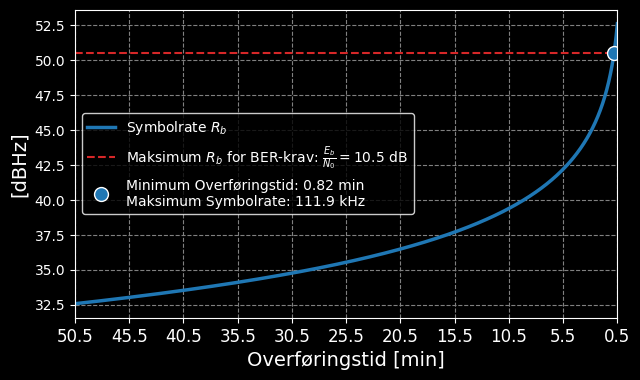

In [2]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

EIRP = 39.3 # dBW
Ls = 212.0 # dB
L0 = 5.0 # dB
G_r = 46.3 # dBi
N0 = -202.4 # dBW/Hz
Eb_N0_krav = 10.5 # dB
Margin = 10 # dB
Rb_max = EIRP - Ls - L0 + G_r - N0 - Eb_N0_krav - Margin # dBHz

tid= np.linspace(0.5, 50.5, 10000) # min
data_mengde = 5.47e6 # Symboler

data_Rb = data_mengde / (tid * 60) # Baud
data_Rb = 10 * np.log10(data_Rb) # dBHz

# find the index of the first value in data_Rb that is less than Rb_max
index = np.where(data_Rb < Rb_max)[0][0]

# find the corresponding value in tid
tid_min = tid[index] # min
print(f"Min tid: {tid_min:.2f} min")
print(f"Max Rb: {Rb_max:.1f} dBHz / {10**(Rb_max/10)*1e-3:.1f} kHz")


# --- PLOT ---
plt.figure(figsize=(7, 4))
plt.grid(True)

# Plot middelverdiene etter small-scale fading
plt.plot(tid, data_Rb, label=r'Symbolrate $R_b$', color='tab:blue', linewidth=2.5)
plt.axhline(y=Rb_max, color='tab:red', linestyle='--', label=r'Maksimum $R_b$ for BER-krav: $\frac{E_b}{N_0} = 10.5$ dB',linewidth=1.5)
# plot krysningspunkt
plt.plot(tid[index], data_Rb[index], 'o', markersize=10, markeredgecolor='white', markerfacecolor='tab:blue', label=f"Minimum Overføringstid: {tid[index]:.2f} min \nMaksimum Symbolrate: {10**(data_Rb[index]/10)*1e-3:.1f} kHz")
plt.grid(which='both', linestyle='--',  color='gray')
plt.xlabel('Overføringstid [min]', fontsize=14)
plt.ylabel('[dBHz]', fontsize=14)
plt.xticks(np.arange(min(tid), max(tid)+1, 5), fontsize=12)
plt.xlim([min(tid), max(tid)])
# invert x axis
plt.gca().invert_xaxis()
plt.legend(loc='center left', fontsize=10, edgecolor='white')
plt.savefig("Figurer/Link_symbolrate.pdf", bbox_inches="tight")
plt.show()


Minimum Aperturdiameter: 0.27 m


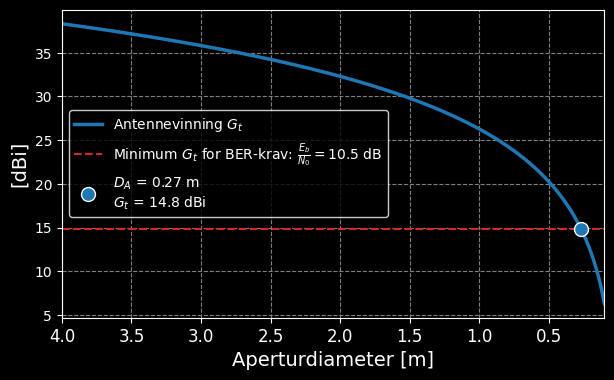

In [3]:
import numpy as np
import matplotlib.pyplot as plt
plt.style.use('dark_background')

P_t =11.4 # dBW
Ls = 212.0 # dB
L0 = 5.0 # dB
G_r = 46.3 # dBi
N0 = -202.4 # dBW/Hz
Eb_N0_krav = 10.5 # dB
Margin = 10 # dB
Rb = 37.4 # dBHz

G_t_min = -P_t + Eb_N0_krav + N0 + Ls + L0 - G_r + Rb + Margin # dBi

eta = 0.8 # Antenneeffektivitet
f= 2.2e9 # Hz
c= 3e8 # m/s
R_earth_moon = 3.844e8 # m

D_a = np.linspace(0.1, 4, 10000) # m
G_t = 10*np.log10(eta * (np.pi * D_a * f / c)**2) # dBi

# finn D_a der G_t er lik G_t_min
index = np.where(G_t > G_t_min)[0][0]
D_a_min = D_a[index] # m

#theta = 70 * c/(D_a*f)
#print(np.deg2rad(theta))
#_theta = 2*R_earth_moon * np.tan(np.deg2rad(theta)/2) *1e-3 # km


print(f"Minimum Aperturdiameter: {D_a_min:.2f} m")
# --- PLOT ---
plt.figure(figsize=(7, 4))
plt.grid(True)

# Plot middelverdiene etter small-scale fading
plt.plot(D_a, G_t, label=r'Antennevinning $G_t$', color='tab:blue', linewidth=2.5)
plt.axhline(y=G_t_min, color='tab:red', linestyle='--', label=r'Minimum $G_t$ for BER-krav: $\frac{E_b}{N_0} = 10.5$ dB',linewidth=1.5)
# plot krysningspunkt
plt.plot(D_a[index], G_t[index], 'o', markersize=10, markeredgecolor='white', markerfacecolor='tab:blue', label=r"$D_A$ = "+f"{D_a[index]:.2f} m \n"+r"$G_t$ = "+f"{G_t[index]:.1f} dBi")
plt.grid(which='both', linestyle='--',  color='gray')
plt.xlabel('Aperturdiameter [m]', fontsize=14)
plt.ylabel('[dBi]', fontsize=14)
plt.xticks(np.arange(0, 10+0.1, 0.5), fontsize=12)
plt.xlim([min(D_a), max(D_a)])
# invert x axis
plt.gca().invert_xaxis()
plt.legend(loc='center left', fontsize=10, edgecolor='white')
plt.savefig("Figurer/Link_antenne.pdf", bbox_inches="tight")
plt.show()